# Estatísticas: idade e sexo confundem o modelo?

Este notebook responde **três perguntas** sobre a task configurada em `STATS_CFG` (default: sMCI × pMCI, volume, SVM, protocolo `abs`).

---

## Roteiro

| # | Pergunta | O que aparece na saída |
|---|----------|------------------------|
| **1** | sMCI e pMCI têm **idade ou sexo diferentes**? | Tabela com médias/proporções + **p** (Mann-Whitney / χ²) |
| **2** | Um modelo com **só idade** ou **só sexo** separa as classes? | AUC + **p por permutação** |
| **3** | O modelo de **imagem** vai além da demografia? | AUC imagem + diferença (ΔAUC) com intervalo de confiança |
| **4** | **abs** (wide) é melhor que **t1_only**? | ΔAUC pareado + IC95% + p bootstrap |

---

## Glossário rápido

| Termo | Significado | Como ler |
|-------|-------------|----------|
| **p** | Probabilidade de ver algo **pelo menos tão extremo** quanto o observado, *se não houvesse efeito real* | **p < 0,05** → evidência de diferença/efeito; **p ≥ 0,05** → compatível com acaso |
| **AUC** | Área sob a curva ROC (0,5 = moeda; 1,0 = perfeito) | Quão bem scores **ordenam** pMCI acima de sMCI |
| **Mann-Whitney U** | Compara **distribuições de idade** entre dois grupos (não só médias) | Usado na secção 1 para idade |
| **χ² (qui-quadrado)** | Testa se **sexo** e **diagnóstico** estão associados numa tabela de contagens | Usado na secção 1 para sexo |
| **Permutação** | Embaralha rótulos sMCI/pMCI 5000× e recalcula AUC → “seria sorte?” | Usado na secção 2 (`p_permutation`) |
| **Bootstrap** | Reamostra pacientes com reposição para IC do ΔAUC | Usado nas linhas “imagem − idade/sexo” |

---

## Regra prática (α = 0,05)

- **Secção 1:** p alto → grupos **demograficamente parecidos** (bom: menos confusão).
- **Secção 2, só idade/sexo:** AUC ≈ 0,5 e p alto → demografia **não explica** o desempenho.
- **Secção 2, imagem:** AUC > 0,5 e p baixo → sinal **real**; se ΔAUC (IC95%) > 0 → imagem **melhor** que idade/sexo.

Saída CSV: `stats_{task}_{modality}.csv`

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score

from ablation_analysis import explode_patient_predictions, prepare_ablation_df

BASE = Path("csvs/longitudinal_4_groups")
LONG_CSV = BASE / "ablation" / "hippocampus" / "vol_long.csv"

PROTOCOL_ROOTS = {
    "abs": BASE / "ablation_results",
    "t1_only": BASE / "ablation_results_t1_only",
}

MODS_COMPARE = ("vol", "shape", "texture", "disp", "all")


@dataclass(frozen=True)
class StatsCfg:
    task: str = "smci_pmci"
    groups: tuple[str, str] = ("sMCI", "pMCI")
    positive_group: str = "pMCI"
    modality: str = "vol"
    model_key: str = "svm"
    with_combat: bool = False
    selection_mode: str = "l1_stable"
    protocol: str = "abs"
    n_perm: int = 5000
    n_bootstrap: int = 5000
    seed: int = 42


ALPHA = 0.05  # limiar usual em artigos (5%)


def ler_p(p: float, *, contexto: str = "") -> str:
    """Texto curto para interpretar um p-value."""
    tag = "significativo" if p < ALPHA else "não significativo"
    acaso = "rejeitamos hipótese nula" if p < ALPHA else "compatível com acaso"
    prefix = f"{contexto}: " if contexto else ""
    return f"{prefix}{tag} (p={p:.4f}) — {acaso}"


STATS_CFG = StatsCfg()
print("Configuração atual:")
print(f"  task={STATS_CFG.task}  grupos={STATS_CFG.groups}")
print(f"  imagem: protocolo={STATS_CFG.protocol}  modality={STATS_CFG.modality}  model={STATS_CFG.model_key}")
print(f"  permutações={STATS_CFG.n_perm}  bootstrap={STATS_CFG.n_bootstrap}")


Configuração atual:
  task=smci_pmci  grupos=('sMCI', 'pMCI')
  imagem: protocolo=abs  modality=vol  model=svm
  permutações=5000  bootstrap=5000


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def load_cohort(long_path: Path, cfg: StatsCfg) -> pd.DataFrame:
    sub = pd.read_csv(long_path)
    sub = sub[sub["slot"].astype(str) == "baseline"]
    sub = sub.sort_values(["ID_PT", "ID_IMG"]).groupby("ID_PT", as_index=False).first()
    sub = sub[sub["GROUP"].isin(cfg.groups)].copy()
    sub["ID_PT"] = sub["ID_PT"].astype(str)
    sub["y"] = (sub["GROUP"] == cfg.positive_group).astype(int)
    sub["SEX_bin"] = sub["SEX"].map({"M": 0, "F": 1, 0: 0, 1: 1})
    return sub


def permutation_auc_p(
    y: np.ndarray,
    scores: np.ndarray,
    *,
    n_perm: int,
    seed: int,
    bidirectional: bool = False,
) -> tuple[float, float]:
    y = np.asarray(y, dtype=int)
    s = np.asarray(scores, dtype=float)
    if bidirectional:
        auc_obs = float(max(roc_auc_score(y, s), roc_auc_score(y, -s)))
    else:
        auc_obs = float(roc_auc_score(y, s))
    prng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        yp = prng.permutation(y)
        auc_n = max(roc_auc_score(yp, s), roc_auc_score(yp, -s)) if bidirectional else roc_auc_score(yp, s)
        ge += int(auc_n >= auc_obs)
    return auc_obs, (ge + 1) / (n_perm + 1)


def bootstrap_auc_diff(y, scores_a, scores_b, *, n_boot: int, seed: int) -> tuple[float, float, float]:
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    return obs, float(ci_lo), float(ci_hi)


def bootstrap_auc_diff_test(
    y,
    scores_a,
    scores_b,
    *,
    n_boot: int,
    seed: int,
) -> tuple[float, float, float, float, float]:
    """ΔAUC = AUC(a)−AUC(b); IC95%; p one-sided (a>b) e two-sided."""
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    p_one = float((np.sum(diffs <= 0) + 1) / (len(diffs) + 1))
    p_two = float(2 * min(p_one, 1 - p_one))
    return obs, float(ci_lo), float(ci_hi), p_one, p_two


def patient_scores_for_protocol(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    return patient_image_scores(path, cfg).rename(columns={"score_img": "score"})


def nested_cv_auc_univariate(
    X: np.ndarray,
    y: np.ndarray,
    *,
    seed: int,
    k: int = 5,
) -> tuple[float, np.ndarray]:
    """LogReg + scaler em 1 atributo; AUC com predições out-of-fold."""
    X = np.asarray(X, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=int)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=seed)),
    ])
    cv = StratifiedKFold(k, shuffle=True, random_state=seed)
    scores = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    return float(roc_auc_score(y, scores)), scores


def patient_image_scores(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    raw = prepare_ablation_df(pd.read_csv(path))
    mask = (
        (raw["task"] == cfg.task)
        & (raw["modality"] == cfg.modality)
        & (raw["model_key"] == cfg.model_key)
        & (raw["with_combat"] == cfg.with_combat)
        & (raw["selection_mode"] == cfg.selection_mode)
    )
    sub = raw.loc[mask]
    if sub.empty:
        raise FileNotFoundError(f"sem linhas para {cfg} em {path}")
    pat = explode_patient_predictions(sub)
    return pat.groupby("ID_PT", as_index=False).agg(y=("y", "first"), score_img=("score", "mean"))


cohort = load_cohort(LONG_CSV, STATS_CFG)
g0, g1 = STATS_CFG.groups
print(f"n={len(cohort)} | {cohort['GROUP'].value_counts().to_dict()}")

n=188 | {'sMCI': 107, 'pMCI': 81}


## 1. Os grupos têm idade ou sexo diferentes?

**Hipótese nula (H₀):** sMCI e pMCI têm a **mesma** idade e a **mesma** mistura de sexo.

| Variável | Teste | O que o teste usa |
|----------|-------|-------------------|
| Idade | **Mann-Whitney U** | Cada paciente com sua idade (baseline) |
| Sexo | **χ² (qui-quadrado)** | Tabela de **contagens** homem/mulher × grupo |

`valor_a` / `valor_b` = média ou % mulheres (**só descrição**). O **p** vem do teste estatístico.

- **p < 0,05** → grupos **diferem** nessa variável (possível confusão)
- **p ≥ 0,05** → **sem evidência** de diferença (grupos parecidos)

In [26]:
age_a = cohort.loc[cohort["GROUP"] == g0, "AGE"].dropna()
age_b = cohort.loc[cohort["GROUP"] == g1, "AGE"].dropna()
_, p_age_groups = stats.mannwhitneyu(age_a, age_b, alternative="two-sided")

sex_tab = pd.crosstab(cohort["GROUP"], cohort["SEX_bin"], rownames=["GROUP"], colnames=["SEX (0=M, 1=F)"])
_, p_sex_groups, _, _ = stats.chi2_contingency(sex_tab)

demo = pd.DataFrame([
    {
        "variável": "idade",
        "teste": "Mann-Whitney U",
        "grupo_a": g0,
        "valor_a": age_a.mean(),
        "o_que_e_valor": "média idade (anos)",
        "grupo_b": g1,
        "valor_b": age_b.mean(),
        "p": p_age_groups,
    },
    {
        "variável": "sexo",
        "teste": "χ²",
        "grupo_a": g0,
        "valor_a": cohort.loc[cohort["GROUP"] == g0, "SEX_bin"].mean(),
        "o_que_e_valor": "proporção mulheres (F=1)",
        "grupo_b": g1,
        "valor_b": cohort.loc[cohort["GROUP"] == g1, "SEX_bin"].mean(),
        "p": p_sex_groups,
    },
])

print("Tabela de contagens (entrada do χ²):")
display(sex_tab)
print("\nResumo (valores descritivos + p do teste):")
display(demo.round(4))

print("\n── Interpretação ──")
print(ler_p(p_age_groups, contexto="Idade"))
print(ler_p(p_sex_groups, contexto="Sexo"))
if p_age_groups >= ALPHA and p_sex_groups >= ALPHA:
    print("✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.")
else:
    print("⚠ Pelo menos uma variável difere → interpretar modelos da secção 2 com cautela.")

Tabela de contagens (entrada do χ²):


"SEX (0=M, 1=F)",0,1
GROUP,,
pMCI,48,33
sMCI,69,38



Resumo (valores descritivos + p do teste):


,variável,teste,grupo_a,valor_a,o_que_e_valor,grupo_b,valor_b,p
0,idade,Mann-Whitney U,sMCI,75.0374,média idade (anos),pMCI,74.6296,0.5664
1,sexo,χ²,sMCI,0.3551,proporção mulheres (F=1),pMCI,0.4074,0.5618



── Interpretação ──
Idade: não significativo (p=0.5664) — compatível com acaso
Sexo: não significativo (p=0.5618) — compatível com acaso
✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.


## 2. Idade ou sexo sozinhos separam sMCI de pMCI?

**Pergunta:** se treinarmos um classificador com **apenas** idade (ou apenas sexo), ele acerta mais que o acaso?

**Pipeline (mesmos pacientes da secção 1):**

1. **Regressão logística** com 1 variável (idade ou sexo binário)
2. **5-fold CV estratificado** → score out-of-fold por paciente (sem vazamento)
3. **AUC** mede ordenação pMCI > sMCI
4. **Permutação (5000×):** embaralha rótulos sMCI/pMCI; **p** = fração de permutações com AUC ≥ observado

| Coluna | Significado |
|--------|-------------|
| `auc` | Desempenho do modelo (0,5 = moeda) |
| `p_permutation` | p do teste de permutação |
| `confunde` | `True` se AUC > 0,55 **e** p < 0,05 (demografia explica parte do sinal) |
| `ci95` / `imagem_superior` | Só nas linhas **imagem − idade/sexo**: ΔAUC e se IC95% > 0 |

**Leitura rápida:** AUC ≈ 0,5 + p alto → variável **não discrimina**. Imagem com AUC alto + ΔAUC com IC95% > 0 → sinal **além** da demografia.

Passo A — modelo só com IDADE (nested CV + permutação)
  AUC = 0.456  |  não significativo (p=0.8546) — compatível com acaso

Passo B — modelo só com SEXO
  AUC = 0.507  |  não significativo (p=0.4277) — compatível com acaso

Passo C — scores de IMAGEM (abs / vol)
  AUC = 0.679  |  significativo (p=0.0002) — rejeitamos hipótese nula  |  n pacientes = 188

Passo D — imagem melhor que demografia? (bootstrap do ΔAUC)
  ΔAUC (imagem − idade) = 0.223  IC95% [0.102, 0.341]
  ΔAUC (imagem − sexo)  = 0.172  IC95% [0.047, 0.297]

── Tabela resumo ──


,modelo,features,auc,p_permutation,ci95,confunde,imagem_superior
0,só idade,AGE,0.4555,0.8546,,False,NaN
1,só sexo,SEX_bin,0.5067,0.4277,,False,NaN
2,imagem (abs),vol,0.6787,0.0002,,False,NaN
3,imagem − idade,ΔAUC,0.2232,NaN,"[0.102, 0.341]",NaN,True
4,imagem − sexo,ΔAUC,0.1720,NaN,"[0.047, 0.297]",NaN,True



── Conclusão automática ──
• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.
• Imagem (abs) discrimina significativamente (AUC ≈ 0.68).
• Imagem supera idade: ganho médio ΔAUC ≈ 0.22 (IC95% não cruza zero).
• Imagem supera sexo: ganho médio ΔAUC ≈ 0.17 (IC95% não cruza zero).


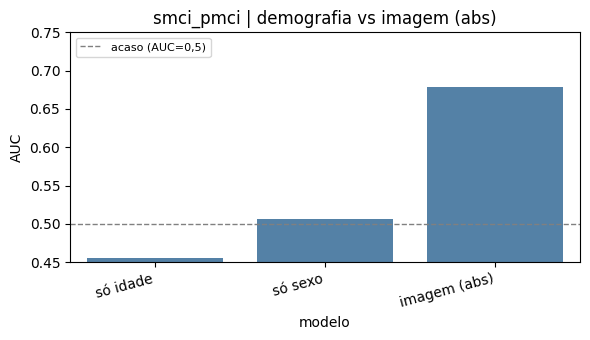

In [ ]:
cfg = STATS_CFG
pt = cohort[["ID_PT", "y", "AGE", "SEX_bin"]].dropna().copy()
y = pt["y"].to_numpy()

print("Passo A — modelo só com IDADE (nested CV + permutação)")
auc_age, scores_age = nested_cv_auc_univariate(pt["AGE"].to_numpy(), y, seed=cfg.seed)
_, p_age = permutation_auc_p(y, scores_age, n_perm=cfg.n_perm, seed=cfg.seed)
print(f"  AUC = {auc_age:.3f}  |  {ler_p(p_age)}")

print("\nPasso B — modelo só com SEXO")
auc_sex, scores_sex = nested_cv_auc_univariate(pt["SEX_bin"].to_numpy(), y, seed=cfg.seed + 1)
_, p_sex = permutation_auc_p(y, scores_sex, n_perm=cfg.n_perm, seed=cfg.seed + 1)
print(f"  AUC = {auc_sex:.3f}  |  {ler_p(p_sex)}")

pt = pt.assign(score_age=scores_age, score_sex=scores_sex)

print(f"\nPasso C — scores de IMAGEM ({cfg.protocol} / {cfg.modality})")
results_path = PROTOCOL_ROOTS[cfg.protocol] / cfg.modality / "ablation_results_all.csv"
img = patient_image_scores(results_path, cfg).merge(pt, on=["ID_PT", "y"], how="inner")
y_m = img["y"].to_numpy()

auc_img, p_img = permutation_auc_p(
    y_m, img["score_img"].to_numpy(), n_perm=cfg.n_perm, seed=cfg.seed + 2,
)
print(f"  AUC = {auc_img:.3f}  |  {ler_p(p_img)}  |  n pacientes = {len(img)}")

print("\nPasso D — imagem melhor que demografia? (bootstrap do ΔAUC)")
d_age, ci_age_lo, ci_age_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_age"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 3,
)
d_sex, ci_sex_lo, ci_sex_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_sex"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 4,
)
print(f"  ΔAUC (imagem − idade) = {d_age:.3f}  IC95% [{ci_age_lo:.3f}, {ci_age_hi:.3f}]")
print(f"  ΔAUC (imagem − sexo)  = {d_sex:.3f}  IC95% [{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]")

summary = pd.DataFrame([
    {"modelo": "só idade", "features": "AGE", "auc": auc_age, "p_permutation": p_age},
    {"modelo": "só sexo", "features": "SEX_bin", "auc": auc_sex, "p_permutation": p_sex},
    {"modelo": f"imagem ({cfg.protocol})", "features": cfg.modality, "auc": auc_img, "p_permutation": p_img},
    {"modelo": "imagem − idade", "features": "ΔAUC", "auc": d_age, "p_permutation": np.nan},
    {"modelo": "imagem − sexo", "features": "ΔAUC", "auc": d_sex, "p_permutation": np.nan},
])
summary["ci95"] = ["", "", "", f"[{ci_age_lo:.3f}, {ci_age_hi:.3f}]", f"[{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]"]
summary["confunde"] = [
    bool(auc_age > 0.55 and p_age < ALPHA),
    bool(auc_sex > 0.55 and p_sex < ALPHA),
    False,
    np.nan,
    np.nan,
]
summary["imagem_superior"] = [np.nan, np.nan, np.nan, ci_age_lo > 0, ci_sex_lo > 0]

print("\n── Tabela resumo ──")
display(summary.round(4))

print("\n── Conclusão automática ──")
if not summary.loc[0, "confunde"] and not summary.loc[1, "confunde"]:
    print("• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.")
else:
    print("• Atenção: idade ou sexo mostram sinal discriminativo → interpretar imagem com cuidado.")

if p_img < ALPHA and auc_img > 0.55:
    print(f"• Imagem ({cfg.protocol}) discrimina significativamente (AUC ≈ {auc_img:.2f}).")
if ci_age_lo > 0:
    print(f"• Imagem supera idade: ganho médio ΔAUC ≈ {d_age:.2f} (IC95% não cruza zero).")
if ci_sex_lo > 0:
    print(f"• Imagem supera sexo: ganho médio ΔAUC ≈ {d_sex:.2f} (IC95% não cruza zero).")

# fig, ax = plt.subplots(figsize=(6, 3.5))
# sns.barplot(data=summary.iloc[:3], x="modelo", y="auc", ax=ax, color="steelblue")
# ax.axhline(0.5, color="0.5", ls="--", lw=1, label="acaso (AUC=0,5)")
# ax.set_ylim(0.45, max(0.75, float(auc_img) + 0.05))
# ax.set_ylabel("AUC")
# ax.set_title(f"{cfg.task} | demografia vs imagem ({cfg.protocol})")
# ax.legend(loc="upper left", fontsize=8)
# plt.xticks(rotation=15, ha="right")
# plt.tight_layout()
# plt.show()

## 3. Como contar a história (exemplo com config default)

Com `smci_pmci`, `vol`, `abs`, resultados típicos:

1. **Secção 1:** idade e sexo **parecidos** entre sMCI e pMCI (p ≈ 0,56) → coorte equilibrada.
2. **Só idade / só sexo:** AUC ≈ 0,46 e 0,51, p alto → demografia **não** explica conversão.
3. **Imagem:** AUC ≈ 0,68, p baixo → biomarcadores de volume **discriminam**.
4. **ΔAUC:** IC95% de imagem − idade e imagem − sexo **acima de zero** → ganho **não** explicado só por idade/sexo.

**Para o paper:** “Grupos demograficamente comparáveis; modelos univariados de idade e sexo não superaram o acaso; o classificador de neuroimagem manteve AUC significativamente superior (bootstrap ΔAUC).”

A comparação **abs vs t1_only** está na secção 4.

## 4. abs vs t1_only — diferença é significativa?

**Pergunta:** usar features **wide** (3 tempos) melhora vs **só baseline (T1)**?

Mesmos pacientes, mesma config (`task`, `modality`, `model`, `selection`). Teste:

- **ΔAUC** = AUC(abs) − AUC(t1_only), bootstrap por paciente
- **H₀:** ΔAUC = 0
- **p (one-sided):** P(ΔAUC ≤ 0) sob bootstrap — abs **melhor** se p < 0,05 **e** IC95% > 0

> `all_protocols_summary.csv` só mostra AUC agregado; o teste usa `ablation_results_all.csv` (scores por paciente).

Comparação abs vs t1_only | smci_pmci | svm | combat=False | l1_stable



,modality,n_pacientes,auc_abs,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,abs_superior,p_perm_abs,p_perm_t1_only
0,vol,188,0.6787,0.6124,0.0663,-0.0186,0.1503,0.0584,0.1168,False,0.0002,0.0034
1,shape,188,0.6256,0.5430,0.0826,0.0116,0.1525,0.0104,0.0208,True,0.0008,0.1574
2,texture,188,0.5141,0.4720,0.0422,-0.0696,0.1493,0.2274,0.4547,False,0.3627,0.7363
3,disp,188,0.5148,0.4768,0.0381,-0.1094,0.1820,0.3067,0.6135,False,0.3625,0.7091
4,all,188,0.5841,0.4884,0.0957,-0.0199,0.2154,0.0568,0.1136,False,0.0232,0.6013



── Interpretação ──
  vol: ΔAUC=0.066 [-0.019, 0.150]  p(one-sided)=0.0584  → sem evidência
  shape: ΔAUC=0.083 [0.012, 0.152]  p(one-sided)=0.0104  → abs > t1_only
  texture: ΔAUC=0.042 [-0.070, 0.149]  p(one-sided)=0.2274  → sem evidência
  disp: ΔAUC=0.038 [-0.109, 0.182]  p(one-sided)=0.3067  → sem evidência
  all: ΔAUC=0.096 [-0.020, 0.215]  p(one-sided)=0.0568  → sem evidência


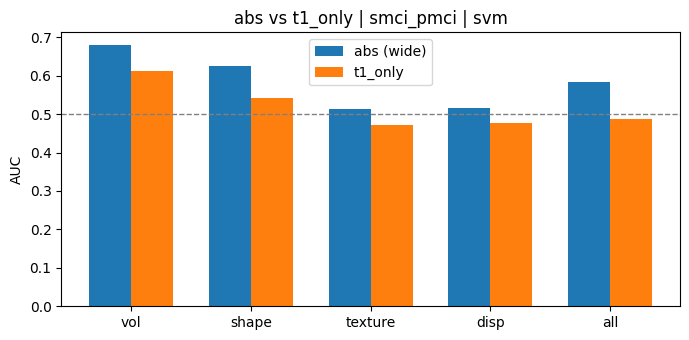

In [ ]:
cfg = STATS_CFG
rows_proto: list[dict] = []

for mod in MODS_COMPARE:
    sub_cfg = StatsCfg(
        task=cfg.task,
        groups=cfg.groups,
        positive_group=cfg.positive_group,
        modality=mod,
        model_key=cfg.model_key,
        with_combat=cfg.with_combat,
        selection_mode=cfg.selection_mode,
        protocol=cfg.protocol,
        n_perm=cfg.n_perm,
        n_bootstrap=cfg.n_bootstrap,
        seed=cfg.seed,
    )
    path_abs = PROTOCOL_ROOTS["abs"] / mod / "ablation_results_all.csv"
    path_t1 = PROTOCOL_ROOTS["t1_only"] / mod / "ablation_results_all.csv"
    if not path_abs.exists() or not path_t1.exists():
        print(f"  skip {mod}: CSV em falta")
        continue

    abs_pat = patient_scores_for_protocol(path_abs, sub_cfg)
    t1_pat = patient_scores_for_protocol(path_t1, sub_cfg)
    paired = abs_pat.merge(t1_pat, on=["ID_PT", "y"], suffixes=("_abs", "_t1"))
    y = paired["y"].to_numpy()

    auc_abs, p_abs = permutation_auc_p(
        y, paired["score_abs"].to_numpy(), n_perm=cfg.n_perm, seed=cfg.seed,
    )
    auc_t1, p_t1 = permutation_auc_p(
        y, paired["score_t1"].to_numpy(), n_perm=cfg.n_perm, seed=cfg.seed + 1,
    )
    d, lo, hi, p_one, p_two = bootstrap_auc_diff_test(
        y,
        paired["score_abs"].to_numpy(),
        paired["score_t1"].to_numpy(),
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 2,
    )
    rows_proto.append({
        "modality": mod,
        "n_pacientes": len(paired),
        "auc_abs": auc_abs,
        "auc_t1_only": auc_t1,
        "delta_auc": d,
        "ci95_lo": lo,
        "ci95_hi": hi,
        "p_bootstrap_one_sided": p_one,
        "p_bootstrap_two_sided": p_two,
        "abs_superior": lo > 0,
        "p_perm_abs": p_abs,
        "p_perm_t1_only": p_t1,
    })

protocol_cmp = pd.DataFrame(rows_proto)
print(f"Comparação abs vs t1_only | {cfg.task} | {cfg.model_key} | combat={cfg.with_combat} | {cfg.selection_mode}\n")
display(protocol_cmp.round(4))

print("\n── Interpretação ──")
for _, r in protocol_cmp.iterrows():
    tag = "abs > t1_only" if r["abs_superior"] else "sem evidência"
    print(
        f"  {r['modality']}: ΔAUC={r['delta_auc']:.3f} "
        f"[{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]  "
        f"p(one-sided)={r['p_bootstrap_one_sided']:.4f}  → {tag}"
    )

# if not protocol_cmp.empty:
#     fig, ax = plt.subplots(figsize=(7, 3.5))
#     x = np.arange(len(protocol_cmp))
#     w = 0.35
#     ax.bar(x - w / 2, protocol_cmp["auc_abs"], w, label="abs (wide)")
#     ax.bar(x + w / 2, protocol_cmp["auc_t1_only"], w, label="t1_only")
#     ax.axhline(0.5, color="0.5", ls="--", lw=1)
#     ax.set_xticks(x)
#     ax.set_xticklabels(protocol_cmp["modality"])
#     ax.set_ylabel("AUC")
#     ax.set_title(f"abs vs t1_only | {cfg.task} | {cfg.model_key}")
#     ax.legend()
#     plt.tight_layout()
#     plt.show()

## 5. Exportar CSV

- `stats_{task}_{modality}.csv` — secção 2 + p-values demográficos
- `stats_abs_vs_t1only_{task}_{model}.csv` — secção 4 (todas as modalidades)

In [ ]:
out = summary.copy()
out.insert(0, "task", cfg.task)
out.insert(1, "modality", cfg.modality)
out.insert(2, "protocol", cfg.protocol)
out["p_idade_entre_grupos"] = p_age_groups
out["p_sexo_entre_grupos"] = p_sex_groups
out_path = BASE / f"stats_{cfg.task}_{cfg.modality}.csv"
# out.to_csv(out_path, index=False)
print(f"Salvo: {out_path}")

if not protocol_cmp.empty:
    proto_out = protocol_cmp.copy()
    proto_out.insert(0, "task", cfg.task)
    proto_out.insert(1, "model_key", cfg.model_key)
    proto_out.insert(2, "with_combat", cfg.with_combat)
    proto_out.insert(3, "selection_mode", cfg.selection_mode)
    proto_path = BASE / f"stats_abs_vs_t1only_{cfg.task}_{cfg.model_key}.csv"
    # proto_out.to_csv(proto_path, index=False)
    print(f"Salvo: {proto_path}")
    display(proto_out.round(4))
else:
    print("Secção 4 vazia — nada a exportar para abs vs t1_only")

Salvo: csvs/longitudinal_4_groups/stats_smci_pmci_vol.csv


,task,modality,protocol,modelo,features,auc,p_permutation,ci95,confunde,imagem_superior,p_idade_entre_grupos,p_sexo_entre_grupos
0,smci_pmci,vol,abs,só idade,AGE,0.4555,0.8546,,False,NaN,0.5664,0.5618
1,smci_pmci,vol,abs,só sexo,SEX_bin,0.5067,0.4277,,False,NaN,0.5664,0.5618
2,smci_pmci,vol,abs,imagem (abs),vol,0.6787,0.0002,,False,NaN,0.5664,0.5618
3,smci_pmci,vol,abs,imagem − idade,ΔAUC,0.2232,NaN,"[0.102, 0.341]",NaN,True,0.5664,0.5618
4,smci_pmci,vol,abs,imagem − sexo,ΔAUC,0.1720,NaN,"[0.047, 0.297]",NaN,True,0.5664,0.5618
